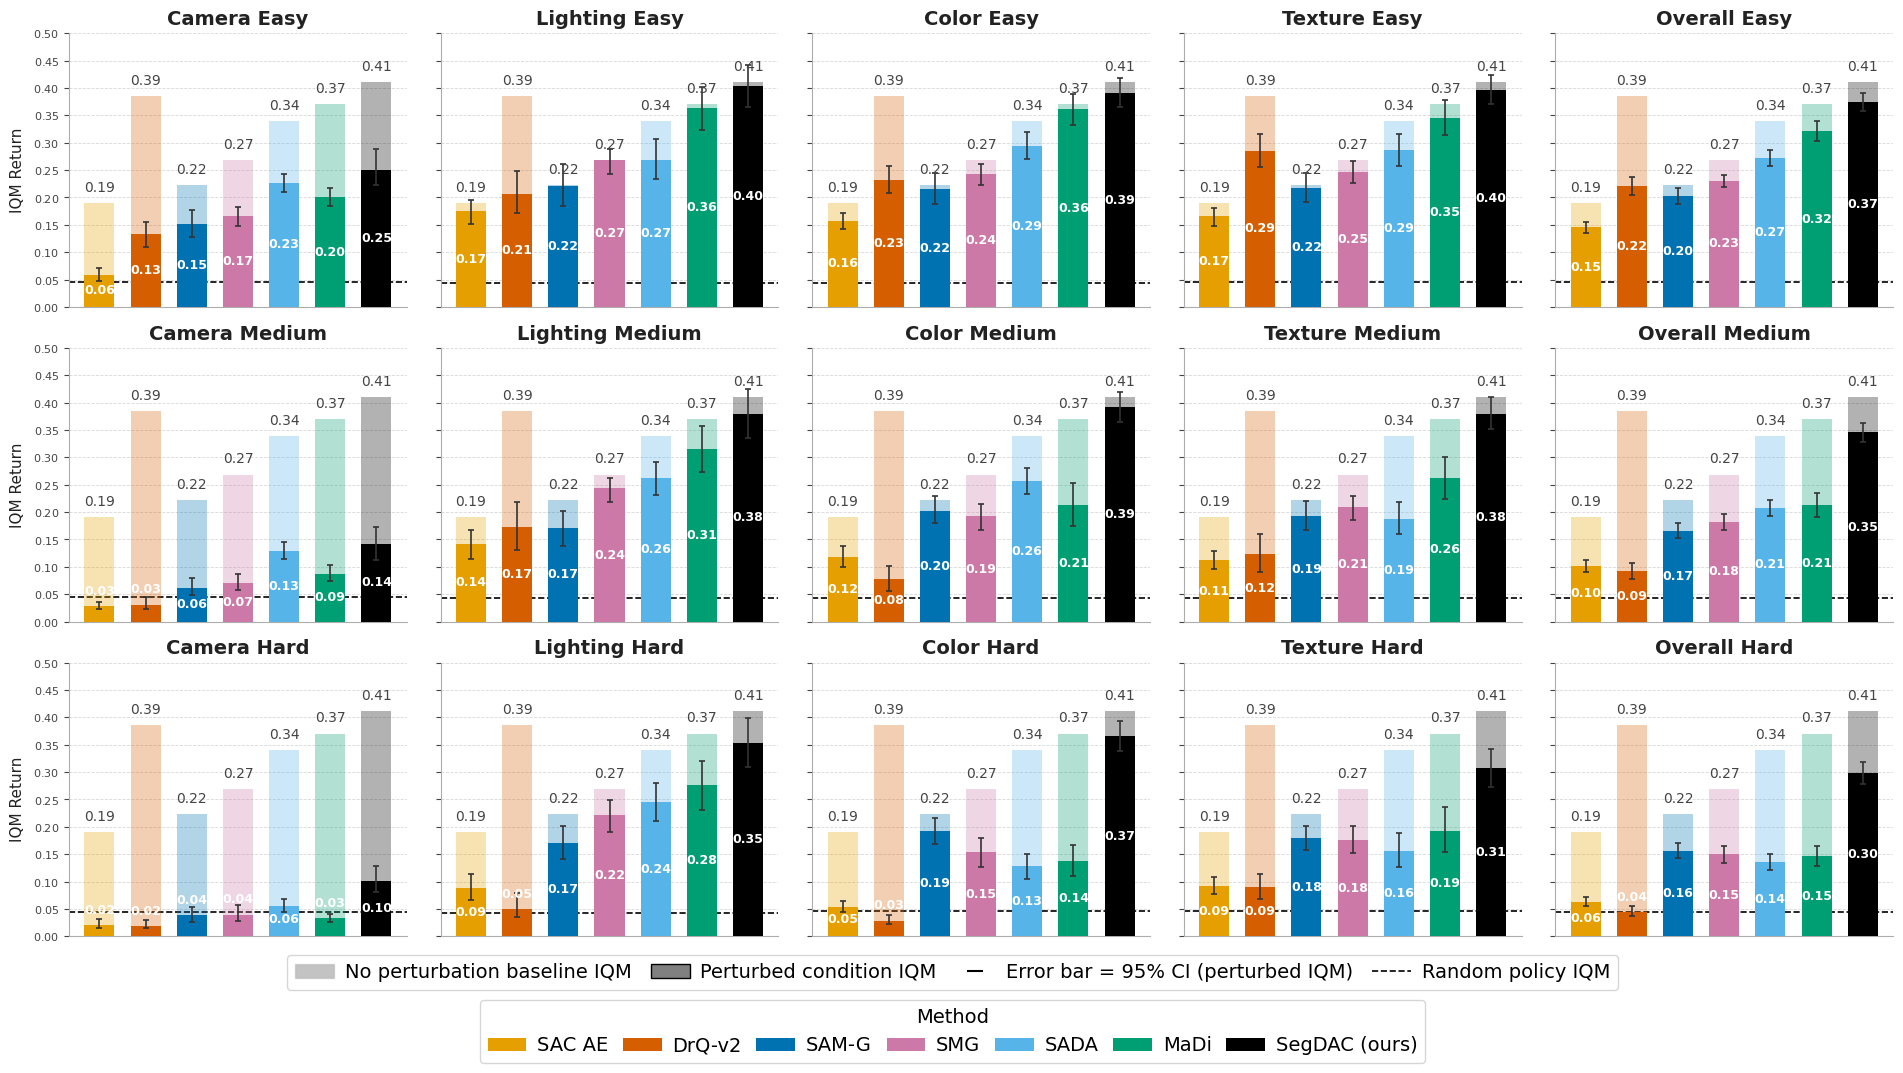

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Arial",
    "DejaVu Sans",
    "Liberation Sans",
    "Helvetica",
]
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

METRIC_NAME = "return"

data = {}

with open("results/test/drqv2_final_aggregated_scores-0.json", "r") as f:
    drqv2_data_content = json.load(f)
data["drqv2"] = drqv2_data_content["drqv2"]

with open(
    "results/test/segdac_sac_sam_enc_decoder_q_cond_final_aggregated_scores-0.json",
    "r",
) as f:
    segdac_data_content = json.load(f)
data["segdac"] = segdac_data_content["segdac_sac_sam_enc_decoder_q_cond"]

with open("results/test/sac_ae_final_aggregated_scores-0.json", "r") as f:
    sac_ae_data_content = json.load(f)
data["sac_ae"] = sac_ae_data_content["sac_ae"]

with open("results/test/madi_final_aggregated_scores-0.json", "r") as f:
    madi_data_content = json.load(f)
data["madi"] = madi_data_content["madi"]

with open("results/test/sada_final_aggregated_scores-0.json", "r") as f:
    sada_data_content = json.load(f)
data["sada"] = sada_data_content["sada"]

with open("results/test/smg_final_aggregated_scores-0.json", "r") as f:
    sada_data_content = json.load(f)
data["smg"] = sada_data_content["smg"]

with open("results/test/samg_final_aggregated_scores-0.json", "r") as f:
    sada_data_content = json.load(f)
data["samg"] = sada_data_content["samg"]

with open("results/test/random_aggregated_scores-0.json", "r") as f:
    sada_data_content = json.load(f)
data["random"] = sada_data_content["random"]

algorithm_plot_config = [
    {"display": "SAC AE", "key": "sac_ae", "color": "#E69F00"},
    {"display": "DrQ-v2", "key": "drqv2", "color": "#D55E00"},
    {"display": "SAM-G", "key": "samg", "color": "#0072B2"},
    {"display": "SMG", "key": "smg", "color": "#CC79A7"},
    {"display": "SADA", "key": "sada", "color": "#56B4E9"},
    {"display": "MaDi", "key": "madi", "color": "#009E73"},
    {"display": "SegDAC (ours)", "key": "segdac", "color": "#000000"},
]

difficulty_plot_config = [
    {"display": "Easy", "key": "easy"},
    {"display": "Medium", "key": "medium"},
    {"display": "Hard", "key": "hard"},
]

condition_plot_config = [
    {"display": "Camera", "key": "camera"},
    {"display": "Lighting", "key": "lighting"},
    {"display": "Color", "key": "color"},
    {"display": "Texture", "key": "texture"},
    {"display": "Overall", "key": "overall"},
]

active_algorithm_plot_config = algorithm_plot_config

algorithm_display_names = [alg["display"] for alg in active_algorithm_plot_config]
bar_colors_ordered = [alg["color"] for alg in active_algorithm_plot_config]
algorithms_x_pos = np.arange(len(algorithm_display_names))

fig, axes = plt.subplots(
    len(difficulty_plot_config),
    len(condition_plot_config),
    figsize=(19, 10.5),
    sharey=True,
)

if len(difficulty_plot_config) == 1 and len(condition_plot_config) == 1:
    axes = np.array([[axes]])
elif len(difficulty_plot_config) == 1:
    axes = axes.reshape(1, -1)
elif len(condition_plot_config) == 1:
    axes = axes.reshape(-1, 1)

fig.subplots_adjust(
    left=0.035,
    right=0.995,
    top=0.99,
    bottom=0.13,
    wspace=0.10,
    hspace=0.15,
)

y_ticks = np.arange(0, 0.55, 0.05)
bar_width = 0.65

error_bar_style = {
    "ecolor": "#333333",
    "elinewidth": 1.2,
    "capsize": 2.5,
    "capthick": 1.2,
}

for i, difficulty_config in enumerate(difficulty_plot_config):
    difficulty_key = difficulty_config["key"]

    for j, condition_config in enumerate(condition_plot_config):
        condition_key = condition_config["key"]
        ax = axes[i, j]

        current_perturbed_means = []
        perturbed_errors_below_list = []
        perturbed_errors_above_list = []
        baseline_means = []

        for algo_config in active_algorithm_plot_config:
            algo_key = algo_config["key"]

            baseline_mean_val = data[algo_key]["no_perturb"]["overall"][METRIC_NAME][
                "iqm"
            ][0]
            baseline_means.append(baseline_mean_val)

            perturb_data_dict = data[algo_key]["perturb_per_diff_per_cat"][
                difficulty_key
            ][condition_key][METRIC_NAME]
            perturbed_mean_val = perturb_data_dict["iqm"][0]
            ci_low = perturb_data_dict["ci"][0][0]
            ci_high = perturb_data_dict["ci"][1][0]

            current_perturbed_means.append(perturbed_mean_val)
            perturbed_errors_below_list.append(perturbed_mean_val - ci_low)
            perturbed_errors_above_list.append(ci_high - perturbed_mean_val)

        current_perturbed_yerr = [
            perturbed_errors_below_list,
            perturbed_errors_above_list,
        ]

        # Baseline bars (faded)
        ax.bar(
            algorithms_x_pos,
            baseline_means,
            color=bar_colors_ordered,
            width=bar_width,
            alpha=0.3,
            zorder=2,
        )

        # Perturbed bars
        ax.bar(
            algorithms_x_pos,
            current_perturbed_means,
            yerr=current_perturbed_yerr,
            color=bar_colors_ordered,
            width=bar_width,
            error_kw=error_bar_style,
            zorder=3,
        )

         # Random policy
        random_mean_val = data["random"]["perturb_per_diff_per_cat"][
            difficulty_key
        ][condition_key][METRIC_NAME]["iqm"][0]
        ax.axhline(
            y=random_mean_val,
            color="black",
            linestyle="--",
            linewidth=1.2,
            zorder=1.5,
        )

        # Text annotations
        for algo_index, algo_config in enumerate(active_algorithm_plot_config):
            algo_x_position = algorithms_x_pos[algo_index]

            # Perturbed value
            perturbed_val = current_perturbed_means[algo_index]
            perturbed_text_content = f"{perturbed_val:.2f}"
            y_pos_perturbed_text = max(perturbed_val / 2, 0.03)
            va_perturbed = "center"
            if perturbed_val < 0.05:
                y_pos_perturbed_text = (
                    perturbed_val + 0.015 if perturbed_val > 0 else 0.015
                )
                va_perturbed = "bottom"

            ax.text(
                algo_x_position,
                y_pos_perturbed_text,
                perturbed_text_content,
                ha="center",
                va=va_perturbed,
                fontsize=9,
                color="white",
                fontweight="bold",
                zorder=4,
            )

            # Baseline value
            baseline_val = baseline_means[algo_index]
            baseline_text_content = f"{baseline_val:.2f}"
            offset_above_baseline = 0.015

            y_pos_baseline_text = baseline_val + offset_above_baseline
            if baseline_val < 0.005:
                y_pos_baseline_text = offset_above_baseline

            ax.text(
                algo_x_position,
                y_pos_baseline_text,
                baseline_text_content,
                ha="center",
                va="bottom",
                fontsize=10,
                color="#444444",
                zorder=5,
            )

        # Titles and axes formatting
        ax.set_title(
            f'{condition_config["display"]} {difficulty_config["display"]}',
            fontsize=14,
            fontweight='bold',
            color="#222222",
            pad=6,
        )
        ax.set_ylim(0, 0.5)
        ax.set_yticks(y_ticks)

        # Remove x-axis ticks & labels
        ax.set_xticks([])
        ax.set_xticklabels([])
        ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

        ax.tick_params(axis="y", colors="#444444", labelsize=8)

        if j == 0:
            ax.set_ylabel("IQM Return", fontsize=11, color="#222222", labelpad=6)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("#ADADAD")
        ax.spines["bottom"].set_color("#ADADAD")

        ax.grid(axis="y", linestyle="--", color="#D8D8D8", linewidth=0.6, zorder=0)
        ax.set_axisbelow(True)

# ----------------------------------------------------------------------
# LEGEND 1 — Baseline vs Perturbed vs CI  (upper row at bottom)
# ----------------------------------------------------------------------
legend1_handles = [
    mpatches.Patch(
        facecolor="dimgray",
        alpha=0.4,
        edgecolor="darkgray",
        label="No perturbation baseline IQM",
    ),
    mpatches.Patch(
        facecolor="gray",
        edgecolor="black",
        label="Perturbed condition IQM",
    ),
    Line2D(
        [],
        [],
        color="black",
        marker="_",
        linestyle="None",
        markersize=12,
        markeredgewidth=1.5,
        label="Error bar = 95% CI (perturbed IQM)",
    ),
    Line2D(
        [],
        [],
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="Random policy IQM",
    ),
]

fig.legend(
    handles=legend1_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.07),
    fontsize=14,
    frameon=True,
    ncol=4,
    columnspacing=1.0,
    handletextpad=0.55,
)

# ----------------------------------------------------------------------
# LEGEND 2 — Methods (colors)  (bottom row)
# ----------------------------------------------------------------------
method_handles = [
    mpatches.Patch(facecolor=alg["color"], label=alg["display"])
    for alg in active_algorithm_plot_config
]

fig.legend(
    handles=method_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.00001),
    fontsize=14,
    title_fontsize=14,
    title="Method",
    ncol=len(method_handles),
    frameon=True,
    columnspacing=0.75,
    handletextpad=0.55,
)

plt.show()

output_folder = Path("results/test/plots")
output_folder.mkdir(parents=True, exist_ok=True)
fig.savefig(
    str(output_folder / "visual_generalization_plots.pdf"),
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)
